# 03 - Modelagem Não Supervisionada (Clusterização de Aeroportos)

## Objetivo

Neste notebook será aplicada uma abordagem de aprendizado não supervisionado para agrupar aeroportos dos EUA por perfil operacional, respondendo à pergunta-guia do desafio:

> É possível agrupar aeroportos dos EUA em perfis semelhantes de comportamento operacional?

Diferente da modelagem supervisionada (notebook 02), aqui não há um target a prever. O objetivo é descritivo: descobrir agrupamentos naturais a partir das características operacionais de cada aeroporto, sem rótulos prévios.

Por isso usamos features que só são conhecidas depois do voo acontecer (atraso médio, taxa de cancelamento, decomposição de causas) - as mesmas que provocariam leakage no modelo de classificação supervisionado.

A análise utiliza K-Means para a clusterização e PCA para visualização dos grupos em duas dimensões.


## Dataset

- `flights.csv` — 5.819.079 voos comerciais nos EUA durante 2015 (31 colunas)
- `airports.csv` — cadastro de 322 aeroportos com geolocalização
- `airlines.csv` — cadastro de 14 companhias aéreas

## Nossa abordagem técnica

Vamos seguir o pipeline padrão de aprendizado não-supervisionado visto nas aulas:

1. **EDA focada** — estatísticas descritivas + visualizações + tratamento de nulos das variáveis que vamos usar
2. **Engenharia de features** — agregar milhões de voos por aeroporto de origem, gerando um *perfil* com 9 variáveis (volume, atrasos, cancelamentos, decomposição de causas)
3. **Padronização** — `StandardScaler` para deixar todas as features na mesma escala (essencial para K-Means e PCA)
4. **K-Means + Método do Cotovelo** — escolher o número de clusters `K` de forma objetiva e treinar o modelo
5. **PCA (Análise de Componentes Principais)** — projetar o espaço para conseguir *visualizar* os clusters
6. **Interpretação** — boxplots por cluster, heatmap dos componentes, listagem dos aeroportos representativos de cada grupo
7. **Apresentação crítica** — conclusões e limitações do modelo.

## Por que essa abordagem?

- **Cluster + PCA** é a combinação que mais se encaixa no que estudamos: o K-Means agrupa no espaço completo (9 dimensões) preservando toda a informação, e o PCA serve apenas para visualização. 
- **Aeroporto** como unidade de análise, se alinha à pergunta-guia do enunciado e gera um bom volume de linhas, adequado para o K-Means (nem pouco, nem ruidoso demais).
- **Dataset completo** vamos usar o dataset completo porque agregações por aeroporto a partir da população real são mais corretas do que estimativas a partir de uma amostra.

---

## Setup

Antes de iniciarmos vamos realizar a importação das bibliotecas que serão utilizadas no notebook:

- **Numpy e  Pandas** para manipulação de arrays e dataframes
- **Matplotlib e Seaborn** para gráficos
- **Scikit-learn** para padronização, clusterização e redução de dimensionalidade


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

print('Importação da bibliotecas ocorreram com sucesso!')

Importação da bibliotecas ocorreram com sucesso!


## Carregando os dados

O arquivo `flights.csv` tem mais de 5 milhões de linhas e 31 colunas. Como nossa pergunta é sobre **perfis de aeroportos**, não precisamos de todas as colunas, vamos carregar apenas as que entram na construção do perfil:

- `ORIGIN_AIRPORT`  código do aeroporto de origem (nossa chave)
- `ARRIVAL_DELAY`  atraso na chegada (positivo, negativo ou nulo)
- `CANCELLED`  1 se o voo foi cancelado, 0 caso contrário
- `TAXI_OUT`  tempo de táxi até a decolagem (visão de congestionamento)
- `AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY` decomposição do atraso por causa

Nós também carregamos o arquivo `airports.csv` para depois conseguir mostrar o nome e a cidade dos aeroportos, em vez de só o código IATA.

In [15]:
COLS_FLIGHTS = [
    'ORIGIN_AIRPORT',
    'ARRIVAL_DELAY',
    'CANCELLED',
    'TAXI_OUT',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
]

flights = pd.read_csv('flights.csv', usecols=COLS_FLIGHTS, low_memory=False)
airports = pd.read_csv('airports.csv')

print(f'flights:  {flights.shape[0]:,} linhas x {flights.shape[1]} colunas')
print(f'airports: {airports.shape[0]:,} linhas x {airports.shape[1]} colunas')
print(f'\nMem\u00f3ria usada por flights: {flights.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

flights:  5,819,079 linhas x 9 colunas
airports: 322 linhas x 7 colunas

Memória usada por flights: 689.1 MB


Vamos verificar agora as primeiras linhas dos dois dfs para confirmar que tudo veio como esperamos.

In [16]:
flights.head()

,ORIGIN_AIRPORT,TAXI_OUT,ARRIVAL_DELAY,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,ANC,21.0,-22.0,0,NaN,NaN,NaN,NaN,NaN
1,LAX,12.0,-9.0,0,NaN,NaN,NaN,NaN,NaN
2,SFO,16.0,5.0,0,NaN,NaN,NaN,NaN,NaN
3,LAX,15.0,-9.0,0,NaN,NaN,NaN,NaN,NaN
4,SEA,11.0,-21.0,0,NaN,NaN,NaN,NaN,NaN


In [17]:
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


## EDA

1. Estrutura geral
2. Valores ausentes (e o motivo deles existirem)
3. Distribuição do atraso de chegada
4. Tratamento dos nulos

### 1. Estrutura geral

Aqui já é possível perceber quais colunas tem nulos pelas contagens diferentes.

In [18]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 9 columns):
 #   Column               Dtype  
---  ------               -----  
 0   ORIGIN_AIRPORT       object 
 1   TAXI_OUT             float64
 2   ARRIVAL_DELAY        float64
 3   CANCELLED            int64  
 4   AIR_SYSTEM_DELAY     float64
 5   SECURITY_DELAY       float64
 6   AIRLINE_DELAY        float64
 7   LATE_AIRCRAFT_DELAY  float64
 8   WEATHER_DELAY        float64
dtypes: float64(7), int64(1), object(1)
memory usage: 399.6+ MB


### 2. Valores ausentes

Vamos observar o percentual de nulos em cada coluna.

In [19]:
nulos = pd.DataFrame({
    'nulos': flights.isna().sum(),
    'pct': (flights.isna().sum() / len(flights) * 100).round(2),
})
nulos.sort_values('pct', ascending=False)

,nulos,pct
AIR_SYSTEM_DELAY,4755640,81.72
SECURITY_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
TAXI_OUT,89047,1.53
ORIGIN_AIRPORT,0,0.00
CANCELLED,0,0.00


**Como podemos interpretar:**

- As 5 colunas de decomposição do atraso têm aproximadamente 81% de nulos. Aqui não é necessáriamente um erro, pelo dicionário do BTS essas colunas só são preenchidas quando o atraso passa de 15 minutos. 
- `ARRIVAL_DELAY` e `TAXI_OUT` ficam nulos para voos **cancelados ou desviados** (que somam cerca de 1,5% do total, sem horário real de chegada nem de táxi).

### 3. Distribuição do atraso de chegada

Atraso é nossa variável mais importante. Vamos olhar a distribuição (limitada entre -60 e +180 minutos).

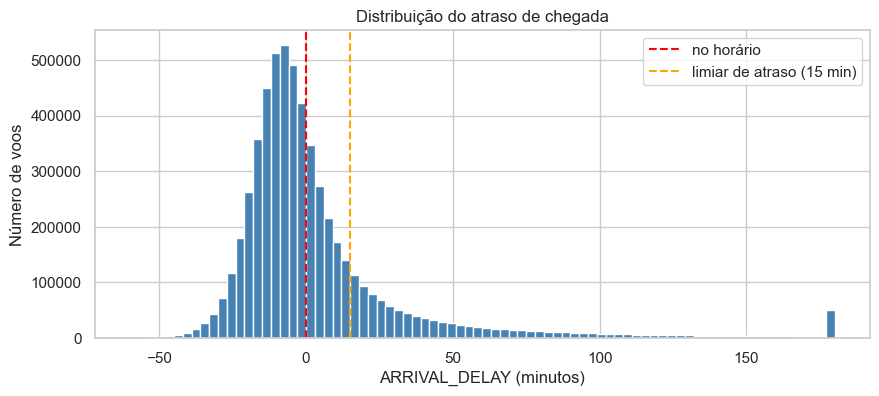

Mediana: -5.0 min
Média:   4.4 min
% atrasados (>=15 min): 18.61%


In [20]:
delay_validos = flights['ARRIVAL_DELAY'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(delay_validos.clip(-60, 180), bins=80, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='no horário')
ax.axvline(15, color='orange', linestyle='--', label='limiar de atraso (15 min)')
ax.set_xlabel('ARRIVAL_DELAY (minutos)')
ax.set_ylabel('Número de voos')
ax.set_title('Distribuição do atraso de chegada')
ax.legend()
plt.show()

print(f'Mediana: {delay_validos.median():.1f} min')
print(f'M\u00e9dia:   {delay_validos.mean():.1f} min')
print(f'% atrasados (>=15 min): {(delay_validos >= 15).mean() * 100:.2f}%')

**Como interpretar nosso gráfico:** a distribuição é assimétrica à direita. A maioria dos voos chega **antes** ou **perto** do horário , mas existe uma cauda longa de voos com atrasos grandes. É essa cauda que nos interessa medir por aeroporto.

Por que 15 minutos como valor de "atrasado"? É o padrão do BTS e do próprio dicionário do ds: as colunas de decomposição de atraso só são preenchidas quando o atraso passa desse valor.

### 6. Tratamento dos nulos

Com base no que vimos, aqui está nossa estratégia:

| Coluna | NaN significa | Tratamento |
|---|---|---|
| `AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY` | voo atrasou menos de 15 min (sem causa atribuída) | preencher com **0** |
| `ARRIVAL_DELAY` | voo cancelado ou desviado | manter NaN (vamos ignorar nas médias) |
| `TAXI_OUT` | voo cancelado ou desviado | manter NaN (vamos ignorar nas médias) |

Aplicamos o preenchimento por zero direto no dataframe:

In [21]:
COLS_CAUSAS = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
]

flights[COLS_CAUSAS] = flights[COLS_CAUSAS].fillna(0)

print('Nulos restantes:')
print(flights.isna().sum())

Nulos restantes:
ORIGIN_AIRPORT              0
TAXI_OUT                89047
ARRIVAL_DELAY          105071
CANCELLED                   0
AIR_SYSTEM_DELAY            0
SECURITY_DELAY              0
AIRLINE_DELAY               0
LATE_AIRCRAFT_DELAY         0
WEATHER_DELAY               0
dtype: int64


## Engenharia de features

Agora vamos transformar os + 5 milhões de voos em uma tabela com uma linha por aeroporto e 9 colunas (o perfil). Esse é o passo central é nessa tabela que o K-Means vamos trabalhar.

| Feature | O que mede |
|---|---|
| `total_voos` | tamanho do aeroporto |
| `pct_atrasados` | % de voos com atraso de chegada ≥ 15 min |
| `atraso_medio` | atraso médio em minutos |
| `pct_cancelados` | % de voos cancelados |
| `taxi_out_medio` | tempo médio de táxi até a decolagem |
| `pct_causa_air_system` | % do atraso causado por controle de tráfego aéreo |
| `pct_causa_airline` | % do atraso causado pela companhia |
| `pct_causa_weather` | % do atraso causado por clima |
| `pct_causa_late_aircraft` | % do atraso causado por efeito-dominó (aeronave chegou atrasada) |

> **Nota sobre as causas:** o dataset tem 5 categorias de causa (air_system, airline, weather, late_aircraft e **security**). Optamos por não incluir `pct_causa_security` no perfil, ela representa em média menos de 0,2% do total de minutos atribuídos a causas, e seu peso é insignificante para diferenciar aeroportos. As 4 causas mantidas somam cerca de 99,8% do total.

Também vamos descartar aeroportos com **menos de 1000 voos no ano** para evitar ruído estatístico (médias instáveis em amostras muito pequenas).

In [22]:
# Marca cada voo como atrasado (>=15 min) ou não
flights['IS_DELAYED'] = (flights['ARRIVAL_DELAY'] >= 15).astype(int)

# Soma total de minutos atribuídos a causas (denominador dos pct_causa_*)
flights['TOTAL_CAUSAS'] = flights[COLS_CAUSAS].sum(axis=1)

agg = flights.groupby('ORIGIN_AIRPORT').agg(
    total_voos=('CANCELLED', 'size'),
    pct_atrasados=('IS_DELAYED', 'mean'),
    atraso_medio=('ARRIVAL_DELAY', 'mean'),
    pct_cancelados=('CANCELLED', 'mean'),
    taxi_out_medio=('TAXI_OUT', 'mean'),
    soma_air_system=('AIR_SYSTEM_DELAY', 'sum'),
    soma_airline=('AIRLINE_DELAY', 'sum'),
    soma_weather=('WEATHER_DELAY', 'sum'),
    soma_late_aircraft=('LATE_AIRCRAFT_DELAY', 'sum'),
    soma_causas=('TOTAL_CAUSAS', 'sum'),
)

# Proporções de cada causa sobre o total de minutos com causa atribuída
agg['pct_causa_air_system']    = agg['soma_air_system']    / agg['soma_causas']
agg['pct_causa_airline']       = agg['soma_airline']       / agg['soma_causas']
agg['pct_causa_weather']       = agg['soma_weather']       / agg['soma_causas']
agg['pct_causa_late_aircraft'] = agg['soma_late_aircraft'] / agg['soma_causas']

FEATURES = [
    'total_voos', 'pct_atrasados', 'atraso_medio', 'pct_cancelados', 'taxi_out_medio',
    'pct_causa_air_system', 'pct_causa_airline', 'pct_causa_weather', 'pct_causa_late_aircraft',
]
perfil_bruto = agg[FEATURES]

# Diagnóstico: quantos aeroportos cada filtro descarta?
n_total = len(perfil_bruto)
mask_iata = perfil_bruto.index.str.len() == 3
nao_iata = perfil_bruto[~mask_iata]
perfil_iata = perfil_bruto[mask_iata]

mask_volume = perfil_iata['total_voos'] >= 1000
perfil = perfil_iata[mask_volume]

print(f'Aeroportos no agrupamento bruto:           {n_total}')
print(f'  Descartados por não serem IATA 3 letras: {(~mask_iata).sum()} '
      f'(volume m\u00e9dio destes: {nao_iata["total_voos"].mean():.0f} voos)')
print(f'  Descartados por terem < 1000 voos:       {(~mask_volume).sum()}')
print(f'Aeroportos no perfil final:                {len(perfil)}')
perfil.head()

Aeroportos no agrupamento bruto:           628
  Descartados por não serem IATA 3 letras: 306 (volume médio destes: 1589 voos)
  Descartados por terem < 1000 voos:       97
Aeroportos no perfil final:                225


,total_voos,pct_atrasados,atraso_medio,pct_cancelados,taxi_out_medio,pct_causa_air_system,pct_causa_airline,pct_causa_weather,pct_causa_late_aircraft
ORIGIN_AIRPORT,,,,,,,,,
ABE,2274,0.176341,6.249663,0.017150,13.408949,0.275627,0.307846,0.012895,0.403632
ABI,2329,0.153714,3.272075,0.041649,9.188004,0.171257,0.340541,0.193444,0.292905
ABQ,19192,0.178043,4.768263,0.011046,11.987672,0.181920,0.298435,0.044881,0.473358
ACT,1612,0.165012,4.658648,0.045285,9.020766,0.093859,0.201962,0.005530,0.697866
ACV,1320,0.219697,7.841483,0.038636,12.151969,0.252210,0.129828,0.000672,0.617290


In [23]:
perfil.describe()

,total_voos,pct_atrasados,atraso_medio,pct_cancelados,taxi_out_medio,pct_causa_air_system,pct_causa_airline,pct_causa_weather,pct_causa_late_aircraft
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000
mean,23448.631111,0.170854,4.571190,0.021042,14.094171,0.232465,0.296212,0.044372,0.426078
std,46774.135435,0.031521,3.107780,0.012536,2.568430,0.068829,0.069915,0.031245,0.080310
min,1001.000000,0.084571,-4.651376,0.002097,8.554709,0.025086,0.080952,0.000000,0.148549
25%,2329.000000,0.154742,2.744483,0.011270,12.595184,0.190935,0.256471,0.022336,0.377598
50%,5149.000000,0.170605,4.485728,0.018842,13.842625,0.235967,0.288166,0.037985,0.424354
75%,18038.000000,0.189751,6.418803,0.028888,15.149638,0.273787,0.341024,0.059155,0.469857
max,346836.000000,0.271757,15.492492,0.077485,27.009783,0.442355,0.513670,0.203465,0.809320


## Padronização

O K-Means usa distância euclidiana para decidir o cluster de cada ponto. Como as 9 features estão em escalas bem diferentes, o volume dominaria tudo e então acabaria com um cluster por tamanho de aeroporto.
para resolver isso vamos aplicar o StandardScaler, cada coluna fica com média 0 e desvio 1, e todas pesam igual no algoritmo.

In [24]:
scaler = StandardScaler()
perfil_scaled = pd.DataFrame(
    scaler.fit_transform(perfil),
    columns=perfil.columns,
    index=perfil.index,
)

print(f'Shape: {perfil_scaled.shape}')
print(f'M\u00e9dia (deve ser ~0): {perfil_scaled.mean().mean():.6f}')
print(f'Desvio (deve ser ~1): {perfil_scaled.std().mean():.6f}')
perfil_scaled.head()

Shape: (225, 9)
Média (deve ser ~0): -0.000000
Desvio (deve ser ~1): 1.002230


,total_voos,pct_atrasados,atraso_medio,pct_cancelados,taxi_out_medio,pct_causa_air_system,pct_causa_airline,pct_causa_weather,pct_causa_late_aircraft
ORIGIN_AIRPORT,,,,,,,,,
ABE,-0.453709,0.174473,0.541292,-0.311148,-0.267381,0.628483,0.166772,-1.009676,-0.280108
ABI,-0.452530,-0.544976,-0.418952,1.647379,-1.914440,-0.891255,0.635460,4.781680,-1.661938
ABQ,-0.091207,0.228579,0.063554,-0.799144,-0.821979,-0.735992,0.031863,0.016315,0.590032
ACT,-0.467894,-0.185736,0.028204,1.938107,-1.979698,-2.018257,-1.351085,-1.245908,3.391796
ACV,-0.474150,1.552999,1.054638,1.406551,-0.757869,0.287515,-2.385129,-1.401741,2.386238


## K-Means com Método do Cotovelo


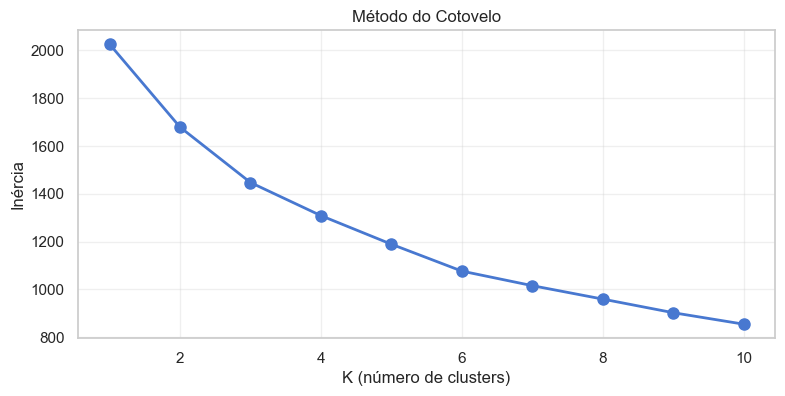

Inércia por K:
  K=1: 2025.0
  K=2: 1678.3
  K=3: 1446.9
  K=4: 1308.5
  K=5: 1189.1
  K=6: 1076.7
  K=7: 1015.9
  K=8: 959.8
  K=9: 902.9
  K=10: 855.0


In [25]:
K_range = range(1, 11)
inercias = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(perfil_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_range), inercias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('K (número de clusters)')
ax.set_ylabel('Inércia')
ax.set_title('Método do Cotovelo')
ax.grid(alpha=0.3)
plt.show()

print('Inércia por K:')
for k, i in zip(K_range, inercias):
    print(f'  K={k}: {i:.1f}')

Observando o gráfico, a curva não tem um cotovelo não é muito destacável, mas começa a aparecer a partir de K=4 Vamos fixar K=4 e treinar o K-Means definitivo.

In [26]:
# valor de K escolhido a partir do método do cotovelo
K = 4

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
kmeans.fit(perfil_scaled)

# Mantemos a atribuição em uma Series separada, sem mutar perfil/perfil_scaled
clusters = pd.Series(kmeans.labels_, index=perfil.index, name='cluster')

print('Aeroportos por cluster:')
print(clusters.value_counts().sort_index())

Aeroportos por cluster:
cluster
0    86
1    26
2    55
3    58
Name: count, dtype: int64


## PCA  visualização

## PCA para visualização

Nosso espaço tem 9 dimensões, impossível de plotar. O PCA resolve achando combinações das 9 features que preservam o máximo de variância.


In [27]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(perfil_scaled)

print(f'Variância explicada por componente: {pca.explained_variance_ratio_.round(3)}')
print(f'Total preservado em 2D: {pca.explained_variance_ratio_.sum() * 100:.1f}%')

Variância explicada por componente: [0.275 0.211]
Total preservado em 2D: 48.6%


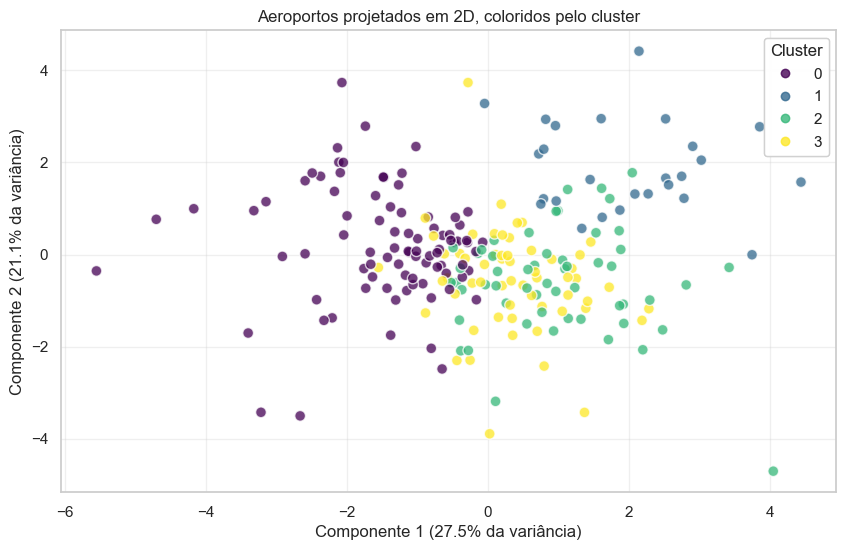

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    componentes[:, 0], componentes[:, 1],
    c=clusters.values, cmap='viridis', alpha=0.75, s=60, edgecolor='white',
)
ax.set_xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
ax.set_ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
ax.set_title('Aeroportos projetados em 2D, coloridos pelo cluster')
legend = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend)
ax.grid(alpha=0.3)
plt.show()

**Como interpretar:** cada ponto é um aeroporto no plano dos 2 primeiros componentes. Quanto mais separadas as cores, mais coesos os clusters. Pontos na borda são casos de fronteira, perfis que poderiam pertencer a mais de um grupo.


## Interpretação dos clusters


### Heatmap dos componentes PCA

Cada componente do PCA é uma combinação linear das 9 features originais. O heatmap mostra o peso de cada feature em cada componente: cores quentes são pesos positivos altos, cores frias são negativos. Isso ajuda a entender o que o eixo X e o eixo Y do scatter representam.

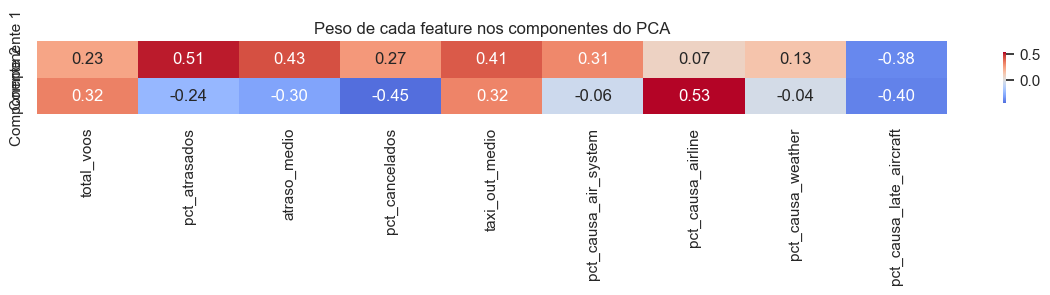

In [29]:
df_comp = pd.DataFrame(
    pca.components_,
    columns=perfil_scaled.columns,
    index=['Componente 1', 'Componente 2'],
)

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(df_comp, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Peso de cada feature nos componentes do PCA')
plt.tight_layout()
plt.show()

### Boxplots por cluster

Aqui comparamos a distribuição das principais features entre os 4 clusters. Caixas em alturas claramente diferentes mostram que aquela feature ajuda a separar os grupos.

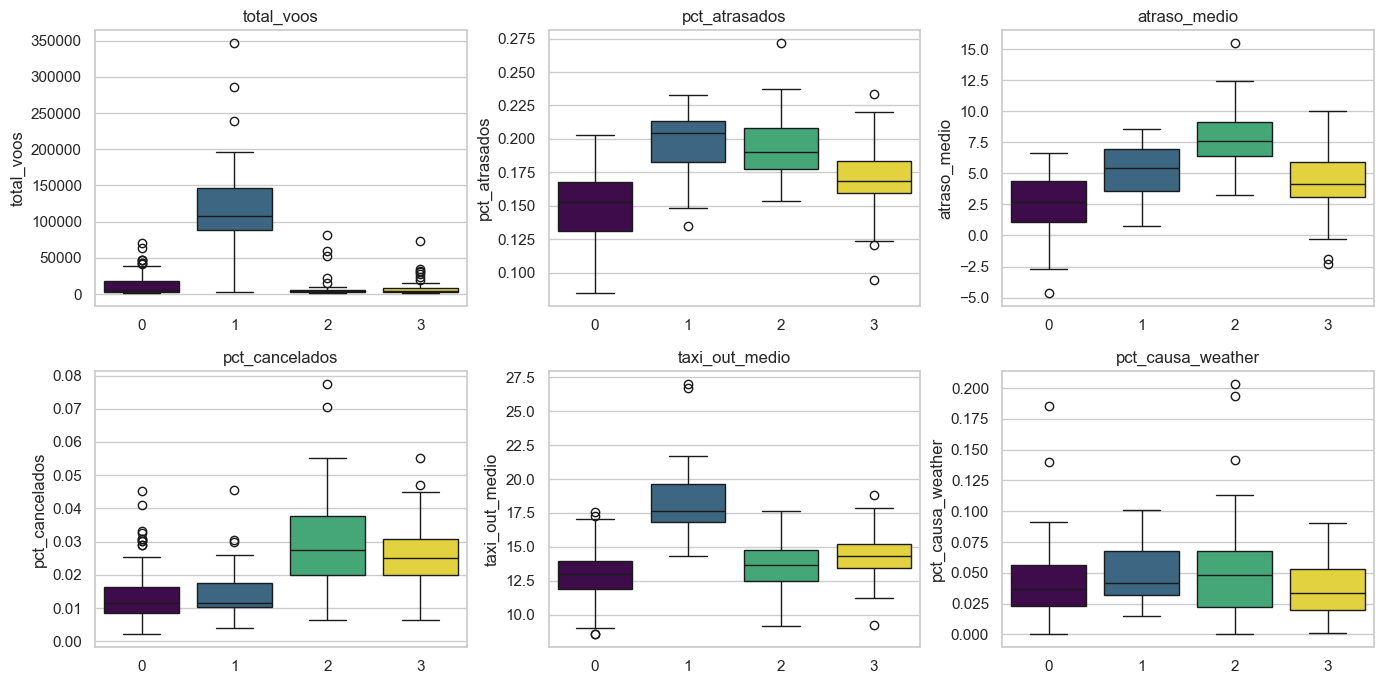

In [30]:
features_destaque = ['total_voos', 'pct_atrasados', 'atraso_medio', 'pct_cancelados',
                     'taxi_out_medio', 'pct_causa_weather']

perfil_com_cluster = perfil.assign(cluster=clusters)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flat, features_destaque):
    sns.boxplot(x='cluster', y=feat, data=perfil_com_cluster,
                hue='cluster', palette='viridis', legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Perfil médio de cada cluster

Tabela com a média de cada feature por cluster. É a forma mais direta de descrever quem é cada grupo.

In [31]:
perfil_medio = perfil.groupby(clusters).mean().round(3)
perfil_medio.index.name = 'cluster'
perfil_medio

,total_voos,pct_atrasados,atraso_medio,pct_cancelados,taxi_out_medio,pct_causa_air_system,pct_causa_airline,pct_causa_weather,pct_causa_late_aircraft
cluster,,,,,,,,,
0,13391.500,0.148,2.546,0.014,12.953,0.189,0.293,0.042,0.474
1,123826.346,0.197,5.033,0.015,18.390,0.242,0.345,0.050,0.362
2,7646.436,0.194,7.952,0.030,13.602,0.217,0.329,0.053,0.400
3,8348.862,0.171,4.161,0.026,14.327,0.307,0.247,0.037,0.408


### Aeroportos representativos de cada cluster

Para melhor identificar vamos listar os 5 aeroportos com **maior volume de voos** dentro de cada cluster, cruzando com o `airports.csv` para mostrar nome, cidade e estado.

In [32]:
perfil_com_info = (
    perfil.assign(cluster=clusters)
          .reset_index()
          .merge(airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']],
                 left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
)

for cluster_id in sorted(perfil_com_info['cluster'].unique()):
    top = (perfil_com_info[perfil_com_info['cluster'] == cluster_id]
           .nlargest(5, 'total_voos')
           [['ORIGIN_AIRPORT', 'AIRPORT', 'CITY', 'STATE', 'total_voos', 'pct_atrasados']])
    print(f'\n=== Cluster {cluster_id} (top 5 por volume) ===')
    print(top.to_string(index=False))


=== Cluster 0 (top 5 por volume) ===
ORIGIN_AIRPORT                                           AIRPORT      CITY STATE  total_voos  pct_atrasados
           SAN San Diego International Airport (Lindbergh Field) San Diego    CA       70207       0.174769
           TPA                       Tampa International Airport     Tampa    FL       63906       0.178309
           BNA                   Nashville International Airport Nashville    TN       47580       0.177112
           PDX                    Portland International Airport  Portland    OR       47085       0.135542
           STL  St. Louis International Airport at Lambert Field  St Louis    MO       46963       0.184677

=== Cluster 1 (top 5 por volume) ===
ORIGIN_AIRPORT                                          AIRPORT              CITY STATE  total_voos  pct_atrasados
           ATL Hartsfield-Jackson Atlanta International Airport           Atlanta    GA      346836       0.162792
           ORD             Chicago O'Hare Inte

### Dando nome aos clusters

Com base no perfil médio, nos boxplots e nos aeroportos representativos, dá para descrever cada grupo numa linguagem mais clara.

O cluster 1 reúne os mega hubs nacionais (26 aeroportos). Volume gigantesco, taxi out alto, atrasos mais ligados à própria companhia. ATL, ORD, DFW, DEN e LAX são os exemplos óbvios.

O cluster 2 tem aeroportos com atraso elevado (55). Não são grandes em volume, mas concentram o pior desempenho do ano, maior atraso médio e maior taxa de cancelamento. MDW, DAL e HOU aparecem aqui.

O cluster 3 agrupa aeroportos sensíveis a controle aéreo (58). A causa dominante vem de gargalos de tráfego (air_system, 30,7%). DCA, CLE, RDU, MKE.

O cluster 0 é o grupo mais numeroso (86) e o mais saudável. Menor atraso médio, menor taxa de atrasados, operação eficiente em aeroportos de porte médio como SAN, TPA, BNA, PDX.

Respondendo à pergunta central: sim, dá para agrupar aeroportos por perfil, e o que separa os grupos não é só o tamanho, é a causa dominante do atraso.

## Apresentação

Fechando o trabalho.

### O que aprendemos

O K-Means achou 4 grupos com perfis bem distintos, e a maior surpresa é que eles não se separam só por tamanho. O que diferencia cada cluster é a causa dominante do atraso. Mega hubs sofrem mais por saturação das companhias, outros aeroportos sofrem por congestionamento do espaço aéreo, e tem um grupo que simplesmente opera com qualidade acima da média.

Vale lembrar que a mediana dos atrasos é negativa (a maioria dos voos chega adiantada), então o que diferencia os aeroportos é o tamanho da cauda dos atrasos grandes, não a média.

O PCA conseguiu projetar tudo, preservando quase metade da variância. Suficiente para visualizar os clusters, mas metade da estrutura fica fora do gráfico.
